In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from helpers.benchmark_plotting import *

models = [
    "vggt", 
    "vggt_ba", 
    # "vggt_edge",
    "vggt_edge_canny",
    # "vggt_edge_teed"
] 
thr = 5

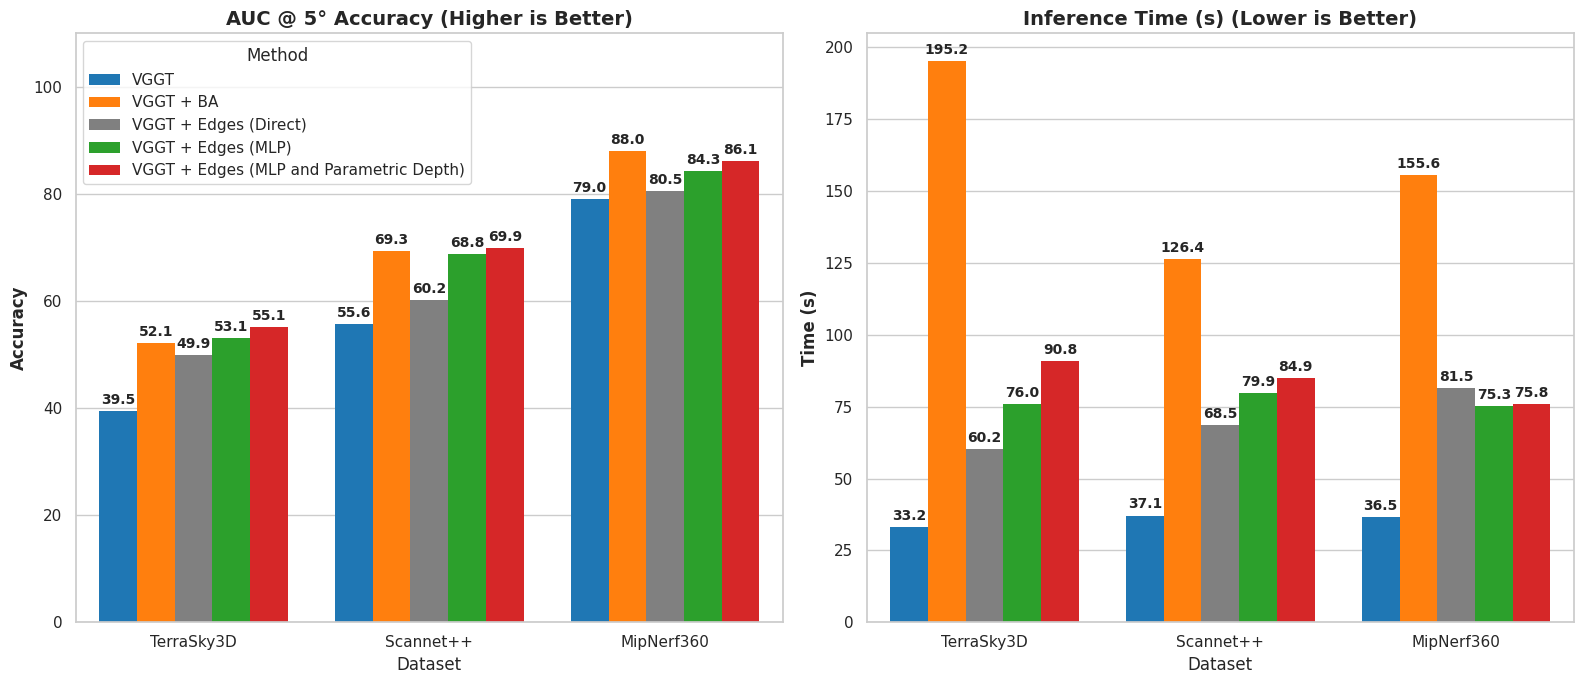

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Define Data (TEED removed)
datasets = ['TerraSky3D', 'Scannet++', 'MipNerf360']

auc_data = {
    'Dataset': datasets,
    'VGGT': [39.48, 55.62, 78.99],
    'VGGT + BA': [52.08, 69.33, 88.01],
    'VGGT + Edges (Direct)': [49.85, 60.16, 80.54],
    'VGGT + Edges (MLP)': [53.15, 68.76, 84.33],
    'VGGT + Edges (MLP and Parametric Depth)': [55.15, 69.87, 86.12] 

}

time_data = {
    'Dataset': datasets,
    'VGGT': [33.20, 37.12, 36.51],
    'VGGT + BA': [195.16, 126.38, 155.59],
    'VGGT + Edges (Direct)': [60.24, 68.5, 81.45],
    'VGGT + Edges (MLP)': [76.03, 79.87, 75.31],
    'VGGT + Edges (MLP and Parametric Depth)': [90.81, 84.86, 75.80]
}

# Define the specific order for the remaining bars
method_order = ['VGGT', 'VGGT + BA', 'VGGT + Edges (Direct)', 'VGGT + Edges (MLP)', 'VGGT + Edges (MLP and Parametric Depth)']

# 2. Define High-Contrast Color Palette (Solid Colors)
custom_palette = {
    'VGGT': '#1f77b4',              # Solid Blue
    'VGGT + BA': '#ff7f0e',         # Solid Orange
    'VGGT + Edges (Direct)': '#808080', # Solid Gray
    'VGGT + Edges (MLP)': '#2ca02c',  # Solid Green
    'VGGT + Edges (MLP and Parametric Depth)': '#d62728'  # Solid Red
}

# Reshape data for plotting
df_auc = pd.DataFrame(auc_data).melt(id_vars='Dataset', var_name='Method', value_name='AUC@5')
df_time = pd.DataFrame(time_data).melt(id_vars='Dataset', var_name='Method', value_name='Time (ms)')

# 3. Setup Figure
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot 1: AUC @ 5° ---
sns.barplot(data=df_auc, x='Dataset', y='AUC@5', hue='Method', 
            hue_order=method_order, ax=ax1, palette=custom_palette, 
            saturation=1, edgecolor=None, linewidth=0)
ax1.set_title('AUC @ 5° Accuracy (Higher is Better)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 110)

for p in ax1.patches:
    h = p.get_height()
    if h > 0:
        ax1.annotate(f'{h:.1f}', (p.get_x() + p.get_width() / 2., h),
                     ha='center', va='center', fontsize=10, fontweight='bold', 
                     xytext=(0, 8), textcoords='offset points')

# --- Plot 2: Inference Time ---
sns.barplot(data=df_time, x='Dataset', y='Time (ms)', hue='Method', 
            hue_order=method_order, ax=ax2, palette=custom_palette, 
            saturation=1, edgecolor=None, linewidth=0)
ax2.set_title('Inference Time (s) (Lower is Better)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Time (s)', fontsize=12, fontweight='bold')

for p in ax2.patches:
    h = p.get_height()
    if h > 0:
        ax2.annotate(f'{h:.1f}', (p.get_x() + p.get_width() / 2., h),
                     ha='center', va='center', fontsize=10, fontweight='bold', 
                     xytext=(0, 8), textcoords='offset points')

# 4. Final Formatting
plt.tight_layout()
ax1.legend(title='Method', loc='upper left', frameon=True)
ax2.get_legend().remove()

plt.show()

## TerraSky3D Test set

In [4]:
# z as z = z*a+b
dataset = "terrasky3D"
df = read_results(dataset, "sparse", models, thr=thr, fill_auc_nan_with_zeros=False)

Results:


,auc@5_vggt,auc@5_vggt_ba,auc@5_vggt_edge_canny,vggt,vggt+ba,vggt+edge+canny
graz_church,72.05,81.30,79.74,37.86,430.21,87.58
graz_main_square,15.97,12.46,30.35,30.72,91.88,80.71
graz_townhall,18.63,60.19,49.53,37.21,144.72,89.79
graz_university,35.55,42.24,36.08,37.86,177.68,93.84
vienna_state_opera,55.17,64.20,80.07,22.35,131.31,102.14
mean,39.48,52.08,55.15,33.20,195.16,90.81


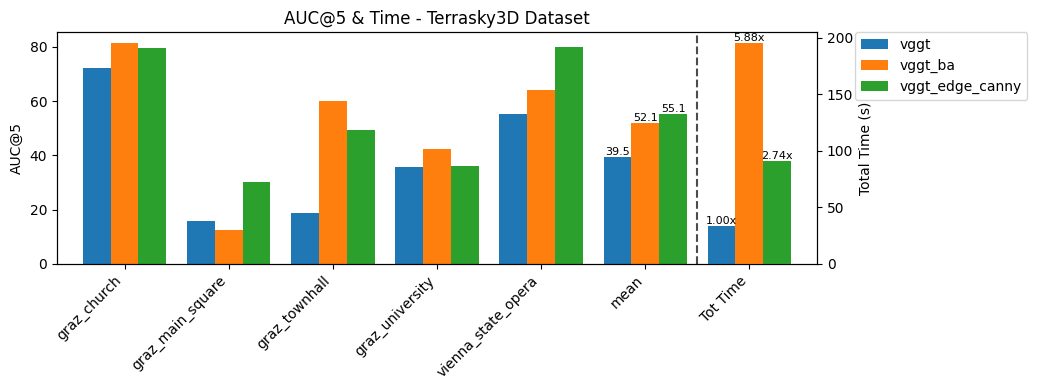

In [5]:
plot_auc5_with_time(df, dataset, models, thr)

## Scannet++

In [6]:
dataset = "scannetpp"
df = read_results(dataset, "sparse_150", models, thr=thr, fill_auc_nan_with_zeros=False)

Results:


,auc@5_vggt,auc@5_vggt_ba,auc@5_vggt_edge_canny,vggt,vggt+ba,vggt+edge+canny
09c1414f1b,40.10,63.75,51.92,40.34,127.74,80.27
1ada7a0617,48.53,63.86,63.15,36.76,111.23,69.98
21d970d8de,66.05,75.68,81.67,37.15,105.56,82.63
286b55a2bf,48.02,72.33,65.77,37.16,182.97,101.83
38d58a7a31,61.19,73.40,78.39,36.70,138.83,70.30
3e8bba0176,72.95,74.06,81.79,36.89,119.08,66.73
40aec5fffa,45.80,49.73,64.16,36.70,115.40,62.95
578511c8a9,50.87,64.36,52.22,36.80,166.05,86.23
5f99900f09,44.93,72.81,58.14,36.74,102.05,59.81
7831862f02,70.09,80.39,86.22,37.14,104.29,62.95


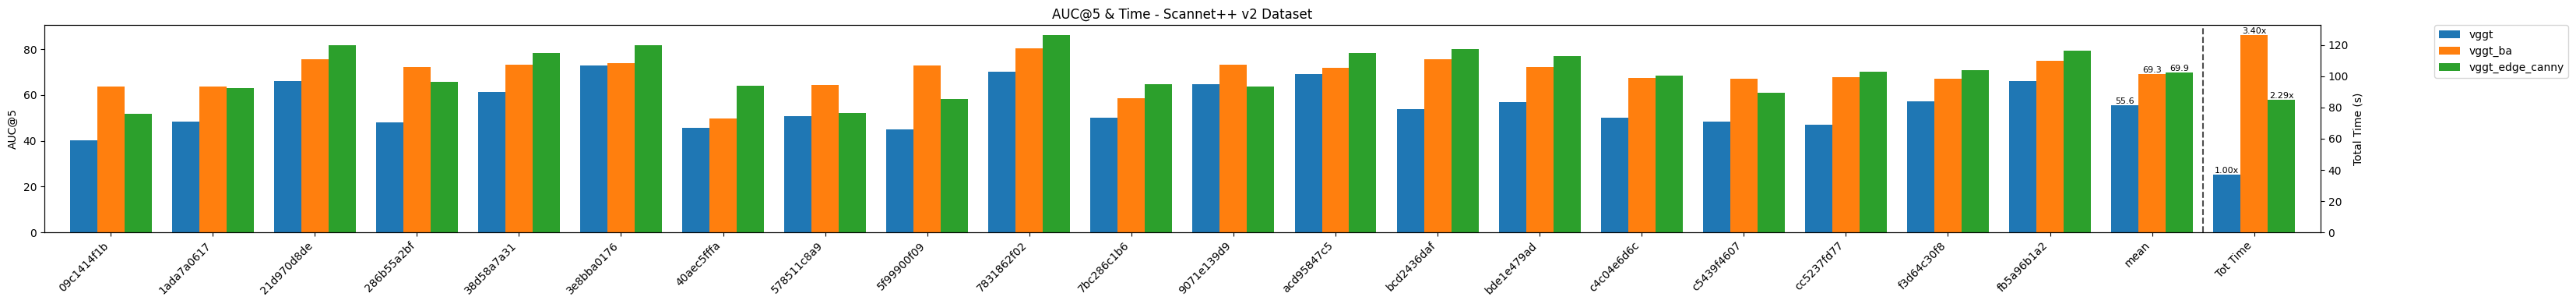

In [7]:
plot_auc5_with_time(df, dataset, models, thr)

## Mip-NeRF360

In [8]:
dataset = "mipnerf360"
df = read_results(dataset, "sparse_150", models, thr=thr, fill_auc_nan_with_zeros=False)

Results:


,auc@5_vggt,auc@5_vggt_ba,auc@5_vggt_edge_canny,vggt,vggt+ba,vggt+edge+canny
bicycle,77.52,85.45,81.99,37.29,124.07,61.89
bonsai,70.75,85.11,77.78,36.11,133.97,85.83
counter,83.64,89.92,91.86,36.39,195.19,76.24
garden,84.90,91.44,90.17,36.31,119.99,83.39
kitchen,87.99,90.15,91.54,36.43,199.70,73.78
room,69.13,86.01,83.39,36.55,160.64,73.64
mean,78.99,88.01,86.12,36.51,155.59,75.80


In [9]:
# scenes = ['bicycle', 'counter', 'garden',  'room', 'bonsai', 'kitchen']
# df_ = df.copy()
# for scene in df.index:
#     if not any([scene.startswith(s) for s in scenes]):
#         df_ = df_.drop(scene)
# df_.loc['mean'] = df_.mean(numeric_only=True)
# df_.round(1)

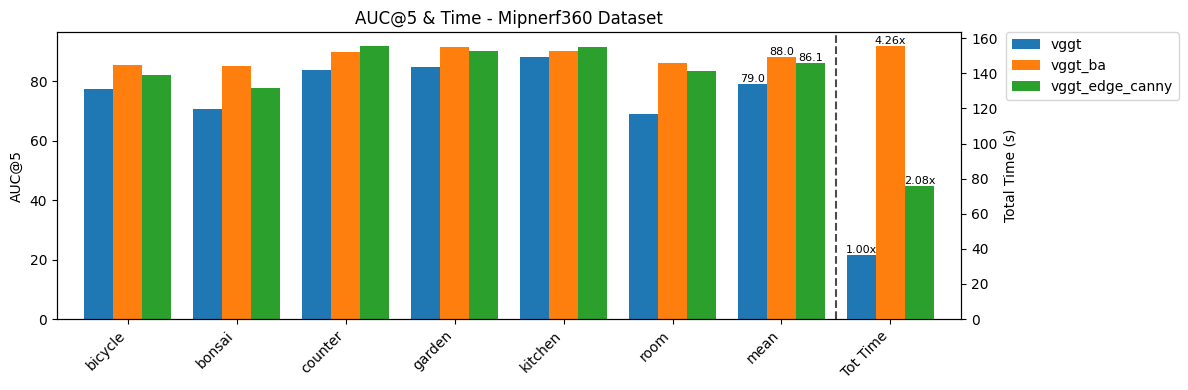

In [10]:
plot_auc5_with_time(df, dataset, models, thr)

## Tank and Temples

In [11]:
dataset = "tt" # tanks_and_temples 
df = read_results(dataset, "sparse_150", models, thr=thr, fill_auc_nan_with_zeros=False)

Results:


,auc@5_vggt,auc@5_vggt_ba,auc@5_vggt_edge_canny,vggt,vggt+ba,vggt+edge+canny
Barn,65.88,72.34,75.62,40.20,220.26,63.14
Caterpillar,70.47,73.97,70.22,37.59,113.13,64.05
Church,22.41,22.28,10.62,37.57,160.57,118.75
Courthouse,44.43,37.76,47.90,38.27,187.14,83.23
Ignatius,71.97,81.30,58.94,38.51,132.21,74.97
Meetingroom,68.90,69.03,54.30,38.37,133.45,66.46
Truck,80.08,82.27,79.01,38.43,131.81,70.75
mean,60.59,62.71,56.66,38.42,154.08,77.34


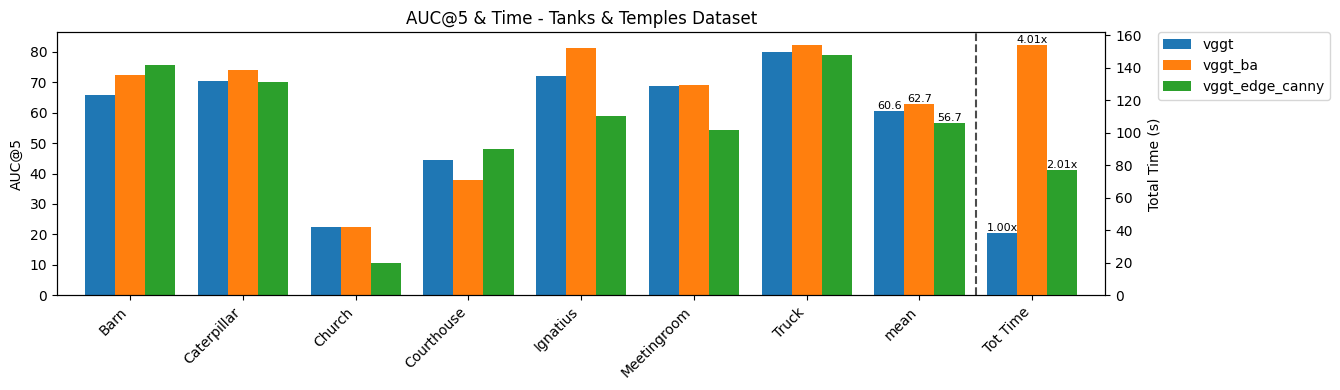

In [12]:
plot_auc5_with_time(df, dataset, models, thr)

In [13]:
.

SyntaxError: invalid syntax (1933637684.py, line 1)

## ETH3D

In [ ]:
dataset = "eth3d"
df = read_results(dataset, "sparse", models, fill_auc_nan_with_zeros=False)

In [ ]:
# scenes = [
#             # "courtyard",
#             "electro",
#             "kicker",
#             "pipes",
#             "relief",
#             "delivery_area",
#             "facade",
#             "office",
#             "playground",
#             "relief_2",
#             "terrains"
#         ]
# for scene in df.index:
#     if not any([scene.startswith(s) for s in scenes]):
#         df = df.drop(scene)
# df.loc['mean'] = df.mean(numeric_only=True)
# df.round(1)

In [ ]:
# keeping only DA3 split
scenes = [
    "botanical_garden",
    "boulders",
    "bridge",
    "door",
    "exhibition_hall",
    "lecture_room",
    "living_room",
    "lounge",
    "observatory",
    "old_computer",
    "statue",
    "terrace_2"
]
for scene in df.index:
    if not any([scene.startswith(s) for s in scenes]):
        df = df.drop(scene)
df.loc['mean'] = df.mean(numeric_only=True)
df.round(1)

In [ ]:
plot_auc5_with_time(df, dataset, models, thr)

In [ ]:
.

## 7Scenes

In [18]:
dataset = "7scenes"
df = read_results(dataset, "colmap/sparse", models, fill_auc_nan_with_zeros=False)

Results:


,auc@5_vggt,auc@5_vggt_ba,auc@5_vggt_edge_canny,vggt,vggt+ba,vggt+edge+canny
chess_seq_03,38.01,39.34,39.34,38.35,264.37,83.64
chess_seq_05,41.01,43.96,46.22,36.62,211.74,78.83
fire_seq_03,47.57,47.81,52.30,38.59,192.03,79.36
fire_seq_04,39.20,43.09,44.57,36.66,230.27,80.94
heads_seq_01,55.00,62.90,56.62,36.53,156.14,119.09
office_seq_02,10.76,10.64,12.39,36.46,153.46,104.68
office_seq_06,10.85,9.19,17.22,36.48,180.22,84.95
office_seq_07,9.67,12.09,12.18,36.44,155.87,70.29
office_seq_09,14.81,15.20,15.80,36.45,231.81,110.93
pumpkin_seq_01,14.41,13.49,15.20,36.46,149.78,71.45


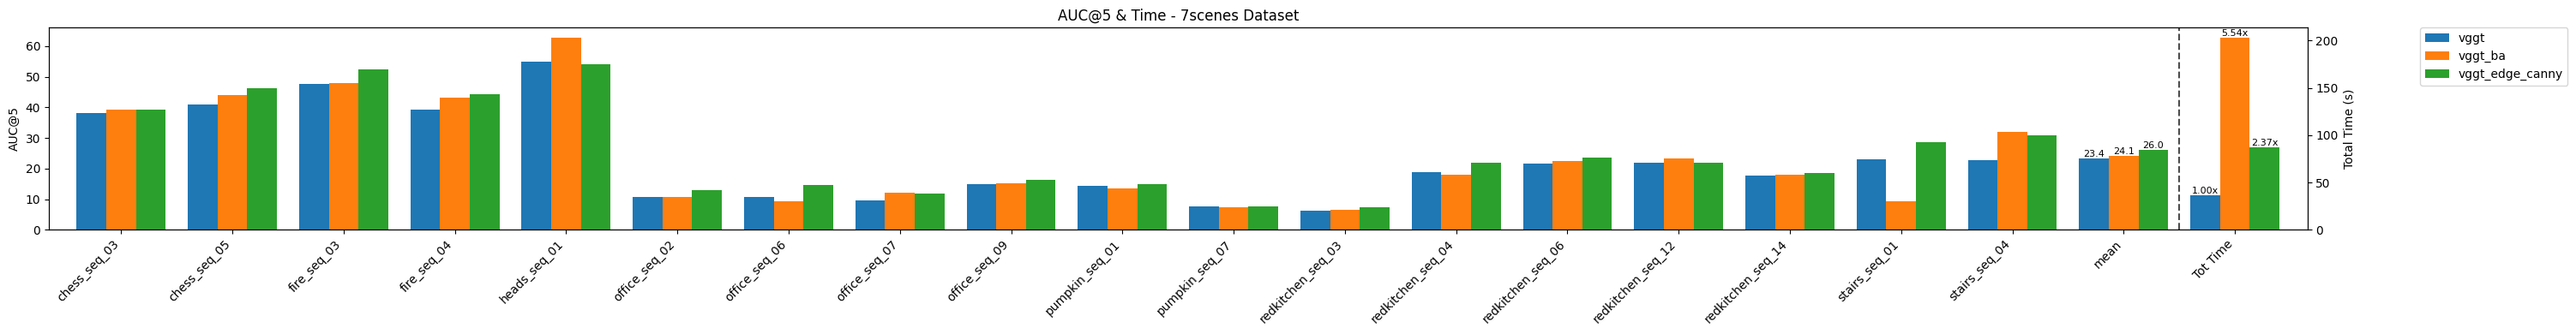

In [17]:
plot_auc5_with_time(df, dataset, models, thr)